# Cell 0 — GPU Availability Check

In [19]:
# Cell 0 — GPU Availability Check
import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)


CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090


# Cell 1 — MLflow setup

In [20]:
# Cell 1 — MLflow setup

import os
import mlflow

# ------------ MLflow (LOCAL to project) -------------
# Notebook is in: Codes/Notebooks/

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
MLRUNS_DIR = os.path.join(PROJECT_ROOT, "mlruns")

# Setting MLflow tracking URI in code 
mlflow.set_tracking_uri(f"file://{MLRUNS_DIR}")

# Choose an experiment name (shows in MLflow UI)
EXPERIMENT_NAME = "01_CNN_AE_Experiments"   


mlflow.set_experiment(EXPERIMENT_NAME)
EXP = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow experiment:", EXP.name, "| id:", EXP.experiment_id)


MLflow tracking URI: file:///home/tekb/Master_Thesis_KB/CodesAndData/mlruns
MLflow experiment: 01_CNN_AE_Experiments | id: 984216377602809561


# Cell 2 — Imports & project path

In [21]:
# Cell 2 — Imports & project path (Code)

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

DATA_DIR = os.path.join(PROJECT_ROOT, "Data", "variation")
CSV_FILE = os.path.join(PROJECT_ROOT, "Data", "parameter.csv")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CSV_FILE:", CSV_FILE)


PROJECT_ROOT: /home/tekb/Master_Thesis_KB/CodesAndData
DATA_DIR: /home/tekb/Master_Thesis_KB/CodesAndData/Data/variation
CSV_FILE: /home/tekb/Master_Thesis_KB/CodesAndData/Data/parameter.csv


# Cell 3a — Reproducibility

In [22]:
# Cell 3a — Reproducibility

from Sources.utils import set_seed, get_device
set_seed(42)
device = get_device()


Seed set to 42
Using device: cuda


# Cell 3b — Run Configuration

In [23]:
# Cell 3b — Run Configuration
# To control eachr run, RUN_CFG is created so that experiments are repeatable and MLflow logging becomes consistent.

# One config dict per run (BEST PRACTICE)
RUN_CFG = {
    # data
    "data_dir": "../Data/variation",
    "csv_file": "../Data/parameter.csv",
    "subset_size": 14000,     # None -> FULL
    "batch_size": 64,
    "seed": 42,

    # (NEW) subset selection strategy
    "subset_sampling": "random",  # "first" or "random"
    "subset_seed": 42,

    # (CLEANUP) geometry normalization (NOT used in stage-1 AE training)
    # We keep these keys so your notebook code will not break,
    # but dataset.py will ignore them and will simply return geo (raw, not normalized).
    "geo_norm": "none",
    "geo_scaler_path": None,

    # representation
    "repr": "ln_phase",

    # model
    "model_type": "cnn_ae",
    "latent_dim": 65,

    # training
    "loss_name": "mse",        # options: "mse" or "huber" (stage-1)
    "huber_delta": 1.0,        # used only if loss_name="huber"
    "lr": 3e-4,
    "epochs": 500,
}

subset_tag = "FULL" if RUN_CFG["subset_size"] is None else f"N{RUN_CFG['subset_size']}"

# loss tag for RUN_NAME (so MLflow shows it clearly)
loss_tag = RUN_CFG["loss_name"]
if RUN_CFG["loss_name"] == "huber":
    loss_tag = f"huber_d{RUN_CFG['huber_delta']}"

RUN_NAME = (
    f"{RUN_CFG['model_type']}_{RUN_CFG['repr']}_{loss_tag}_"
    f"{subset_tag}_ld{RUN_CFG['latent_dim']}_lr{RUN_CFG['lr']}_ep{RUN_CFG['epochs']}"
)

print("RUN_NAME:", RUN_NAME)


RUN_NAME: cnn_ae_ln_phase_mse_N14000_ld65_lr0.0003_ep500


# Cell 4 — Load data (cache-aware)

In [24]:
# Cell 4 — Load data (cache-aware)
# This is where we confirm: random subset is active, cache is correct, and train/val/test IDs are saved.

from Sources.dataset import get_dataloaders

train_loader, val_loader, test_loader, split_info = get_dataloaders(
   data_dir=RUN_CFG["data_dir"],
   csv_file=RUN_CFG["csv_file"],
   batch_size=RUN_CFG["batch_size"],
   subset_size=RUN_CFG["subset_size"],
   seed=RUN_CFG["seed"],
   repr_name=RUN_CFG["repr"],

   # (NEW) subset selection
   subset_sampling=RUN_CFG["subset_sampling"],
   subset_seed=RUN_CFG["subset_seed"],

   # (CLEANUP) geometry options are kept for compatibility,
   # but dataset.py (stage-1) will not normalize geometry here.
   geo_norm=RUN_CFG.get("geo_norm", "none"),
   geo_scaler_path=RUN_CFG.get("geo_scaler_path", None),

   return_split_info=True,
)

print("\nData loading complete")
print("Train size:", len(train_loader.dataset))
print("Val size  :", len(val_loader.dataset))
print("Test size :", len(test_loader.dataset))

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

print("\nSplit info (from dataset.py)")
print("  cache_path:", split_info.get("cache_path"))
print("  seed      :", split_info.get("seed"))
print("  repr_name  :", split_info.get("repr_name"))
print("  subset_sampling:", split_info.get("subset_sampling"))
print("  subset_seed    :", split_info.get("subset_seed"))
print("  geo_norm       :", split_info.get("geo_norm"))
print("  geo_scaler_path:", split_info.get("geo_scaler_path"))


Limit active: Using RANDOM 14000 samples (seed=42).
Loading cached dataset: ../Data/data_cache_ln_phase_N14000_random_seed42_geo_raw.pt

Data loading complete
Train size: 9800
Val size  : 2800
Test size : 1400
Train batches : 154
Val batches   : 44
Test batches  : 22

Split info (from dataset.py)
  cache_path: ../Data/data_cache_ln_phase_N14000_random_seed42_geo_raw.pt
  seed      : 42
  repr_name  : ln_phase
  subset_sampling: random
  subset_seed    : 42
  geo_norm       : raw_in_dataset
  geo_scaler_path: None


/home/tekb/Master_Thesis_KB/CodesAndData/Sources/dataset.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cached = torch.load(self.cache_path, map_location="cpu")  # ma

# Cell 5 — Inspect ONE S4P file (physics sanity check)

In [25]:
# Cell 5 — Inspect ONE S4P file (physics sanity check)

import os
import skrf as rf

# Pick one file from your dataset range
sample_id = 100000 if RUN_CFG["subset_size"] is None else 100000
ntwk = rf.Network(os.path.join(RUN_CFG["data_dir"], f"simu_{sample_id}.s4p"))

freq_mhz = ntwk.f / 1e6
Z = ntwk.z  # [Nf,4,4]

print("Z shape:", Z.shape)
print("freq_mhz shape:", freq_mhz.shape)


Z shape: (334, 4, 4)
freq_mhz shape: (334,)


# Cell 6 — Inspect impedance full matrix plots

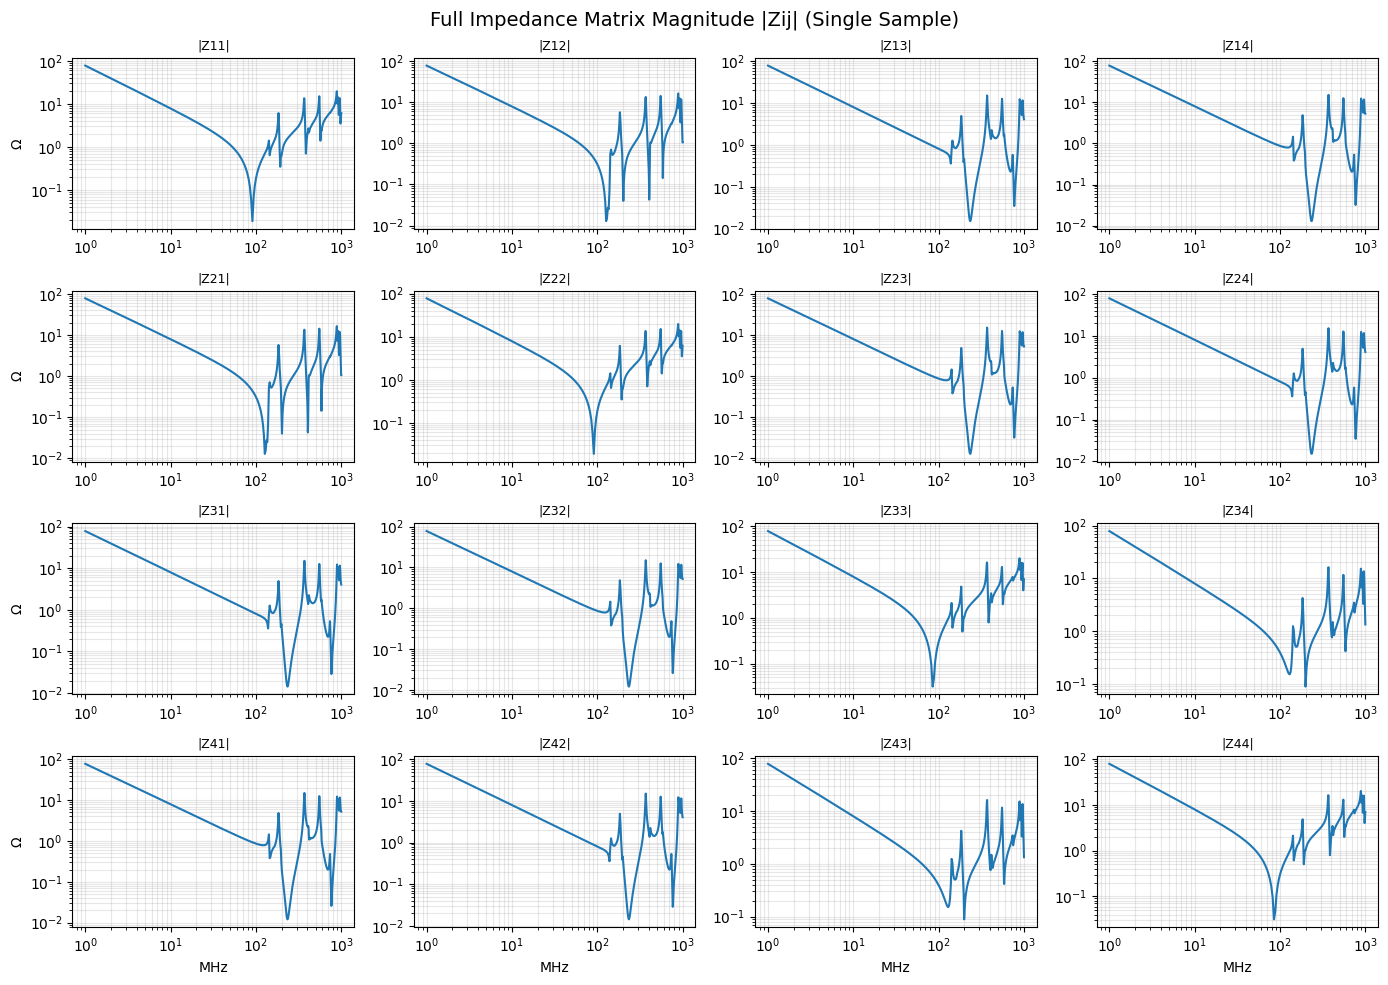

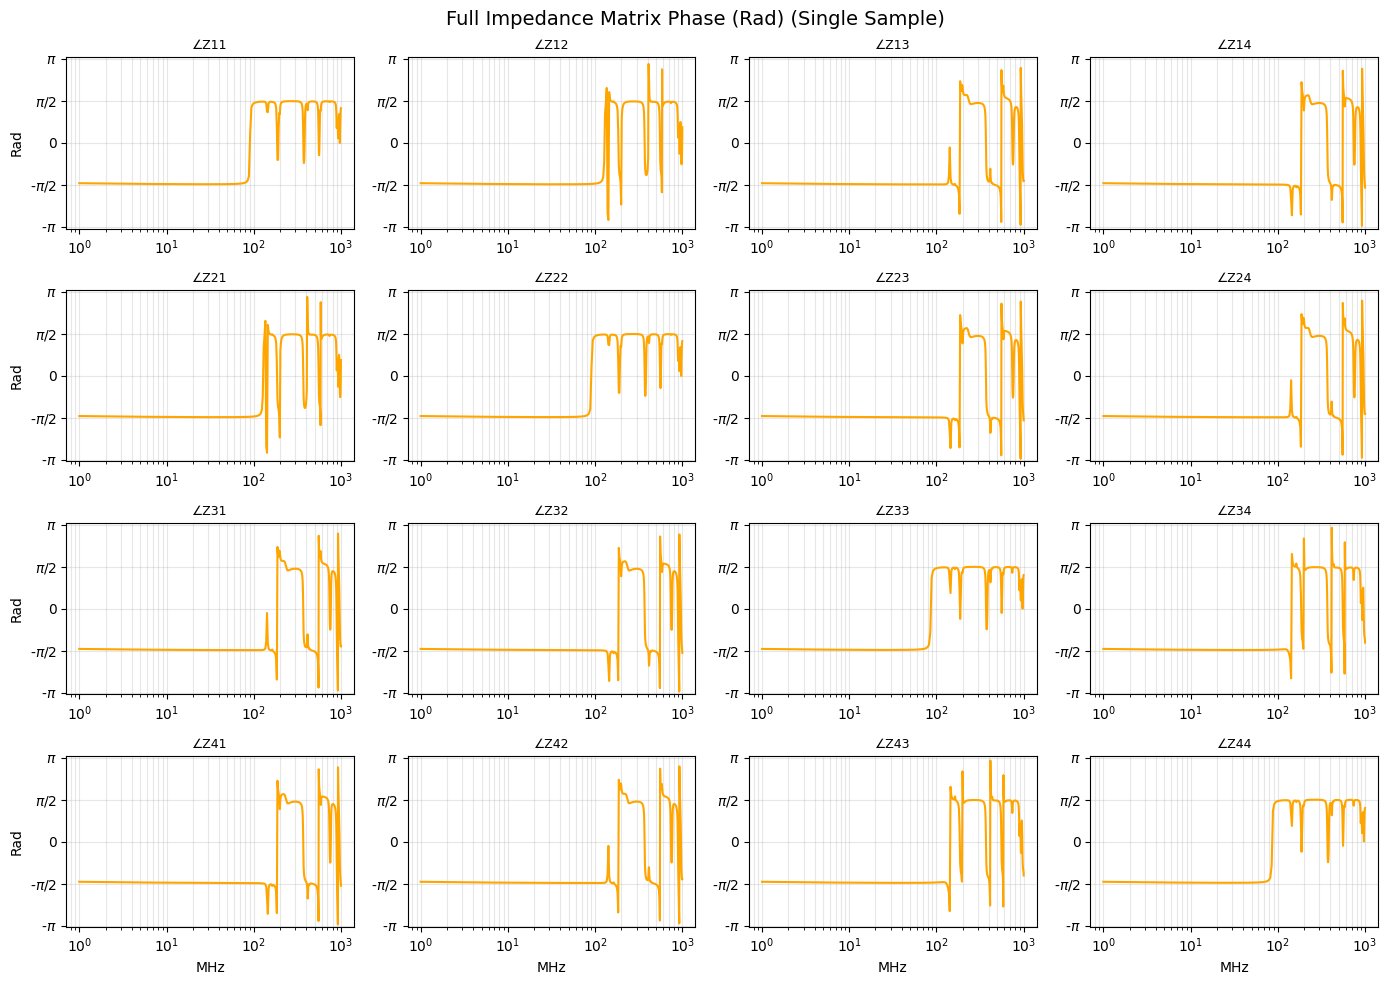

In [163]:
# Cell 6 — Inspect impedance full matrix plots
# Now plots BOTH Magnitude (Ohm) and Phase (Rad) for the full 4x4 matrix.

import matplotlib.pyplot as plt
import numpy as np

# ---------------- Figure 1: Magnitude ----------------
plt.figure(figsize=(14, 10))
for i in range(4):
   for j in range(4):
       ax = plt.subplot(4, 4, i * 4 + j + 1)
       # Magnitude in Ohms (log-log scale)
       ax.loglog(freq_mhz, np.abs(Z[:, i, j]))
       
       ax.set_title(f"|Z{i+1}{j+1}|", fontsize=9)
       ax.grid(True, which="both", alpha=0.3)
       
       if i == 3:
           ax.set_xlabel("MHz")
       if j == 0:
           ax.set_ylabel("Ω")

plt.suptitle("Full Impedance Matrix Magnitude |Zij| (Single Sample)", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------- Figure 2: Phase ----------------
plt.figure(figsize=(14, 10))
for i in range(4):
   for j in range(4):
       ax = plt.subplot(4, 4, i * 4 + j + 1)
       # Phase in Radians (linear y, log x)
       # np.angle returns radians between -pi and +pi
       phase_rad = np.angle(Z[:, i, j])
       
       ax.semilogx(freq_mhz, phase_rad, color="orange")
       
       ax.set_title(f"∠Z{i+1}{j+1}", fontsize=9)
       ax.grid(True, which="both", alpha=0.3)
       # Set limits to visible range (-pi to +pi)
       ax.set_ylim(-3.2, 3.2)
       ax.set_yticks([-3.14, -1.57, 0, 1.57, 3.14])
       ax.set_yticklabels([r'-$\pi$', r'-$\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

       if i == 3:
           ax.set_xlabel("MHz")
       if j == 0:
           ax.set_ylabel("Rad")

plt.suptitle("Full Impedance Matrix Phase (Rad) (Single Sample)", fontsize=14)
plt.tight_layout()
plt.show()


# Cell 7 — Single sample Z11 magnitude & phase

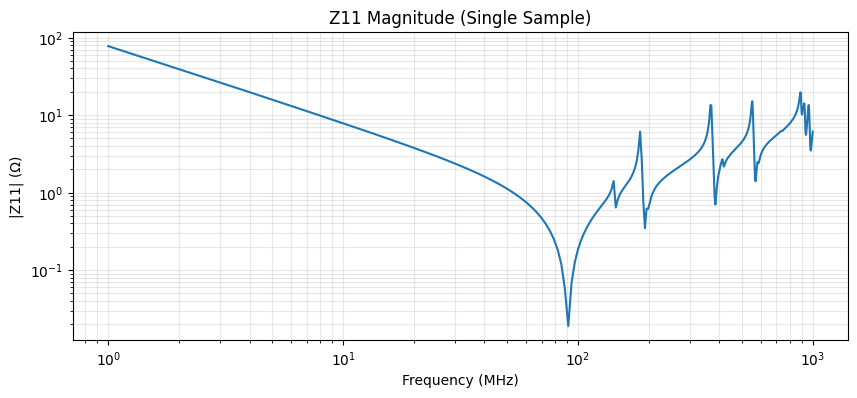

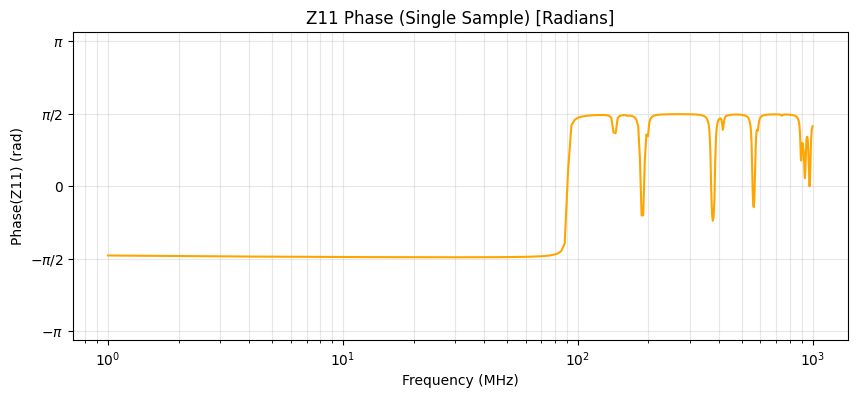

In [164]:
# Cell 7 — Single sample Z11 magnitude & phase

z11 = Z[:, 0, 0]
mag_ohm = np.abs(z11)
phase_rad = np.angle(z11) # Returns value in radians [-pi, +pi]

# Magnitude: log-log (both axes)
plt.figure(figsize=(10, 4))
plt.loglog(freq_mhz, mag_ohm)
plt.grid(True, which="both", alpha=0.3)
plt.xlabel("Frequency (MHz)")
plt.ylabel("|Z11| (Ω)")
plt.title("Z11 Magnitude (Single Sample)")
plt.show()

# Phase: semilog-x (x log, y linear)
# We plot this specifically in Radians to check raw data range
plt.figure(figsize=(10, 4))
plt.semilogx(freq_mhz, phase_rad, color="orange")
plt.grid(True, which="both", alpha=0.3)

# Add nice PI labels for clarity
plt.yticks(
   [-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
   [r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$']
)
plt.ylim(-np.pi - 0.2, np.pi + 0.2)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Phase(Z11) (rad)")
plt.title("Z11 Phase (Single Sample) [Radians]")
plt.show()


# Cell 8 — Model Initialization

In [26]:
# Cell 8 — Model Initialization
# We can log and report trainable parameters for transparency.

from Sources.models import CNNAutoencoder
import mlflow

model = CNNAutoencoder(latent_dim=RUN_CFG["latent_dim"]).to(device)

# (NEW) total trainable parameters
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", f"{n_trainable:,}")

print(model)


Trainable parameters: 367,907
CNNAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(2, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): ReLU()
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(2,), padding=(1,))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_latent): Linear(in_features=2688, out_features=65, bias=True)
  (fc_dec): Linear(in_features=65, out_features=2688, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose1d(64, 32, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(32, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): ReLU()
    (4): ConvTranspose1d(16, 2, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
  )
)


# Cell 9 — Model Training

In [27]:
# Cell 9 — Model Training
# MLflow now stores everything run-scoped: metrics, params, checkpoint, plots, and model

import os
import torch
import mlflow
import mlflow.pytorch

from Sources.trainer import train_model

CHECKPOINT_DIR = os.path.abspath(os.path.join("..", "checkpoints"))
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

RETRAIN = True  # True = force training even if ckpt exists

TRAIN_CFG = {
    "lr": RUN_CFG["lr"],
    "epochs": RUN_CFG["epochs"],
    "patience": 25,
    "min_delta": 1e-6,
    "log_every": 10,

    # loss config (matches trainer.py)
    "loss_name": RUN_CFG["loss_name"],   # "mse" or "huber" (or "physical" if you want)
    "huber_delta": RUN_CFG.get("huber_delta", 1.0),
}

# IMPORTANT: if you re-run Cell 9, make sure no run is currently open
if mlflow.active_run() is not None:
    mlflow.end_run()

ckpt_path = os.path.join(CHECKPOINT_DIR, f"{RUN_NAME}.pt")

# ---------------- MLflow run ----------------
with mlflow.start_run(run_name=RUN_NAME) as run:
    RUN_ID = run.info.run_id
    print(
        "Active MLflow experiment:",
        mlflow.get_experiment(run.info.experiment_id).name,
        "| id:",
        run.info.experiment_id,
    )
    print("MLflow RUN_ID:", RUN_ID)

    # total trainable parameters
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Trainable parameters:", f"{n_trainable:,}")
    mlflow.log_param("n_trainable_params", int(n_trainable))

    subset_tag = "FULL" if RUN_CFG["subset_size"] is None else f"N{RUN_CFG['subset_size']}"

    mlflow.set_tags({
        "project": "PDN_CNN_AE",
        "dataset": subset_tag,
        "repr_name": RUN_CFG["repr"],
        "loss": RUN_CFG["loss_name"],
        "model_type": RUN_CFG["model_type"],
        "impedance_type": "Self Impedance Z11",
    })

    mlflow.log_params({
        "subset_size": RUN_CFG["subset_size"],
        "batch_size": RUN_CFG["batch_size"],
        "seed": RUN_CFG["seed"],
        "repr": RUN_CFG["repr"],
        "latent_dim": RUN_CFG["latent_dim"],
        "lr": RUN_CFG["lr"],
        "epochs": RUN_CFG["epochs"],
        "patience": TRAIN_CFG["patience"],
        "min_delta": TRAIN_CFG["min_delta"],
        "log_every": TRAIN_CFG["log_every"],
        "n_train": len(train_loader.dataset),
        "n_val": len(val_loader.dataset),
        "n_test": len(test_loader.dataset),

        # loss params
        "loss_name": TRAIN_CFG["loss_name"],
        "huber_delta": TRAIN_CFG.get("huber_delta", None),
    })

    mlflow.log_dict(
        {
            "n_total": split_info.get("n_total"),
            "n_train": split_info.get("n_train"),
            "n_val": split_info.get("n_val"),
            "n_test": split_info.get("n_test"),
            "train_sids_first20": split_info["train_sids"][:20],
            "val_sids_first20": split_info["val_sids"][:20],
            "test_sids_first20": split_info["test_sids"][:20],
            "cache_path": split_info.get("cache_path"),
            "repr_name": split_info.get("repr_name"),
            "seed": split_info.get("seed"),
        },
        "data/split_info.json",
    )

    if (not RETRAIN) and os.path.exists(ckpt_path):
        print(f"Found checkpoint, loading instead of training:\n{ckpt_path}")
        checkpoint = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(checkpoint["model_state"])
        stats = checkpoint["stats"]
        history = checkpoint.get("history", None)
        times = checkpoint.get("times", {})
        model.to(device)
        model.eval()
        print("Loaded model and stats from checkpoint.")
    else:
        print("Training now (fresh start)...")
        history, stats, times = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            config=TRAIN_CFG,
            device=device,
            subset_size=RUN_CFG["subset_size"],
            run_name=RUN_NAME,
            checkpoint_dir=CHECKPOINT_DIR,
            run_cfg=RUN_CFG,
        )

    # ---------------- NEW: log best val loss + epoch (normalized domain) ----------------
    best_val_loss_norm = float(times.get("best_val_loss", float("nan")))
    best_epoch = int(times.get("best_epoch", -1)) if times.get("best_epoch", None) is not None else -1
    stopped_epoch = int(times.get("stopped_epoch", -1)) if times.get("stopped_epoch", None) is not None else -1

    mlflow.log_metric("best_val_loss_norm", best_val_loss_norm)
    mlflow.log_metric("best_epoch", best_epoch)
    mlflow.log_metric("stopped_epoch", stopped_epoch)

    print(f"Best validation loss (normalized domain): {best_val_loss_norm:.6f} at epoch {best_epoch}")

    # training time
    train_time_sec = float(times.get("train_time_sec", 0.0))
    train_time_min = float(times.get("train_time_min", train_time_sec / 60.0))
    mlflow.log_metric("train_time_sec", train_time_sec)
    mlflow.log_metric("train_time_min", train_time_min)

    if os.path.exists(ckpt_path):
        mlflow.log_artifact(ckpt_path, artifact_path="checkpoints")
        print("Logged checkpoint to MLflow:", ckpt_path)

    mlflow.pytorch.log_model(model, artifact_path="CNN-AE-Model")
    print("Logged MLflow model under: CNN-AE-Model/")

print("Training cell completed.")


Active MLflow experiment: 01_CNN_AE_Experiments | id: 984216377602809561
MLflow RUN_ID: 6701d8b027d14007aa87314715a67f78
Trainable parameters: 367,907
Training now (fresh start)...
Training CNN-AE on dataset: N14000
Checkpoint file: cnn_ae_ln_phase_mse_N14000_ld65_lr0.0003_ep500.pt
Loss: mse
Learning Rate: FIXED 3.00e-04 (no scheduler)
Early stopping: patience=25, min_delta=1.000000e-06
Logging: print every 10 epochs
[best updated] ep=1 | best_val=0.224986 | lr=3.00e-04
[best updated] ep=10 | best_val=0.020094 | lr=3.00e-04
Epoch 10/500 | Train: 0.021254 | Val: 0.020094 | no_imp=0/25
[best updated] ep=20 | best_val=0.012758 | lr=3.00e-04
Epoch 20/500 | Train: 0.012992 | Val: 0.012758 | no_imp=0/25
[best updated] ep=30 | best_val=0.010161 | lr=3.00e-04
Epoch 30/500 | Train: 0.010040 | Val: 0.010161 | no_imp=0/25
Epoch 40/500 | Train: 0.008267 | Val: 0.008585 | no_imp=1/25
[best updated] ep=50 | best_val=0.007264 | lr=3.00e-04
Epoch 50/500 | Train: 0.007057 | Val: 0.007264 | no_imp=0/25


2026/03/15 18:25:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 18:25:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Early stopping triggered at epoch 375. (best_epoch=350)
Training completed in 87.74 s (1.46 min)
Best validation loss (normalized-domain): 0.003195 at epoch 350
Best validation loss (normalized domain): 0.003195 at epoch 350
Logged checkpoint to MLflow: /home/tekb/Master_Thesis_KB/CodesAndData/checkpoints/cnn_ae_ln_phase_mse_N14000_ld65_lr0.0003_ep500.pt


2026/03/15 18:25:04 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Logged MLflow model under: CNN-AE-Model/
Training cell completed.


# Cell 10 — Training Curve vs Validation Curve

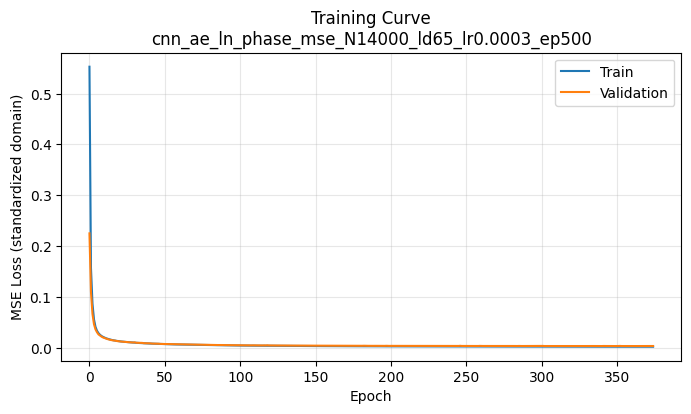

In [28]:
# Cell 10 — Training Curve
# Used to diagnose convergence and overfitting; mostly indicates stable training.

import os
import matplotlib.pyplot as plt
import mlflow
import tempfile

plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.grid(True, alpha=0.3)
plt.xlabel("Epoch")

# loss label depends on config (MSE / complex_MSE / Huber)
plt.ylabel(f"{RUN_CFG['loss_name'].upper()} Loss (standardized domain)")

plt.title(f"Training Curve\n{RUN_NAME}")
plt.legend()

with tempfile.TemporaryDirectory() as tmpdir:
 fig_path = os.path.join(tmpdir, f"training_curve_{RUN_NAME}.png")
 plt.savefig(fig_path, dpi=200, bbox_inches="tight")

 with mlflow.start_run(run_id=RUN_ID):
     mlflow.log_artifact(fig_path, artifact_path="plots")

plt.show()


# Cell 11 — Prepare test reconstruction

In [29]:
# Cell 11 — Prepare test reconstruction
# Evaluation is done in Ohms, which is physically meaningful.

import os
import time
import numpy as np
import torch
import mlflow

# ---- load best checkpoint (portable) ----
ckpt_path = os.path.join(os.path.abspath(os.path.join("..", "checkpoints")), f"{RUN_NAME}.pt")
checkpoint = torch.load(ckpt_path, map_location="cpu")

model.load_state_dict(checkpoint["model_state"])
model.to(device)
model.eval()

# stats were saved on CPU intentionally -> move to device now
stats = checkpoint["stats"]
stats = {k: v.to(device) for k, v in stats.items()}

orig_ln_list, pred_ln_list, orig_phs_list, pred_phs_list, sid_list = [], [], [], [], []

# ---- timing + reconstruction ----
start = time.time()

with torch.no_grad():
   for x, _, sid in test_loader:
       x = x.to(device)

       # normalize using TRAIN stats (NO in-place on x)
       # ln_phase: ch0 = ln(|Z|), ch1 = phase(rad)
       x_norm = x.clone()
       x_norm[:, 0, :] = (x_norm[:, 0, :] - stats["ch0_mean"]) / (stats["ch0_std"] + 1e-6)
       x_norm[:, 1, :] = (x_norm[:, 1, :] - stats["ch1_mean"]) / (stats["ch1_std"] + 1e-6)

       # forward pass
       y_norm, _ = model(x_norm)

       # denormalize BOTH channels back to real units
       y = y_norm.clone()
       y[:, 0, :] = y[:, 0, :] * (stats["ch0_std"] + 1e-6) + stats["ch0_mean"]   # ln(|Z|)
       y[:, 1, :] = y[:, 1, :] * (stats["ch1_std"] + 1e-6) + stats["ch1_mean"]   # phase rad

       # collect ln magnitude + phase
       orig_ln_list.append(x[:, 0, :].detach().cpu().numpy())
       pred_ln_list.append(y[:, 0, :].detach().cpu().numpy())

       orig_phs_list.append(x[:, 1, :].detach().cpu().numpy())
       pred_phs_list.append(y[:, 1, :].detach().cpu().numpy())

       sid_list.append(sid.detach().cpu().numpy())

total_pred_time = time.time() - start

# stack batches
orig_ln = np.vstack(orig_ln_list)
pred_ln = np.vstack(pred_ln_list)
orig_phs = np.vstack(orig_phs_list)
pred_phs = np.vstack(pred_phs_list)
sid = np.concatenate(sid_list)

# convert ln(|Z|) -> Ohms
orig_ohm = np.exp(orig_ln)
pred_ohm = np.exp(pred_ln)

n_test = int(orig_ohm.shape[0])
avg_pred_time_ms = (total_pred_time / max(n_test, 1)) * 1e3

print("Prepared test data:")
print("orig_ohm:", orig_ohm.shape)
print("pred_ohm:", pred_ohm.shape)
print("sid:", sid.shape)
print(f"\nTotal prediction time: {total_pred_time:.2f} s (for {n_test} test samples)")
print(f"Avg prediction time per sample: {avg_pred_time_ms:.3f} ms")

# ---- log inference timing to MLflow (same run) ----
with mlflow.start_run(run_id=RUN_ID):
  mlflow.log_metric("total_pred_time_sec", float(total_pred_time))
  mlflow.log_metric("avg_pred_time_ms", float(avg_pred_time_ms))
  mlflow.log_metric("n_test_eval", int(n_test))


Prepared test data:
orig_ohm: (1400, 334)
pred_ohm: (1400, 334)
sid: (1400,)

Total prediction time: 0.02 s (for 1400 test samples)
Avg prediction time per sample: 0.013 ms


/tmp/ipykernel_1810482/998203739.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location="cpu")


# Cell 12 — Metrics (Ohms + nMAE + dB + Phase)

In [30]:
# Cell 12 — Metrics (Ohms + nMAE + dB + Phase)
# NOTE: moved all metric math into Sources/metrics.py so Stage-2 can reuse it.

import mlflow
from Sources.metrics import compute_metrics, print_metrics

eps = 1e-12

# Use the same frequency grid used in evaluation
freq_hz_eval = freq_mhz * 1e6  # [Nf] Hz

# Compute ALL metrics (same ones you had in the notebook)
metrics = compute_metrics(
    orig_ohm=orig_ohm,
    pred_ohm=pred_ohm,
    freq_hz=freq_hz_eval,
    orig_phs=orig_phs,
    pred_phs=pred_phs,
    eps=eps,
    # bands=None -> uses default low/mid/high split from metrics.py (matches your previous Cell 12)
)

# Print in the same style
print_metrics(metrics, title="CNN AE Performance")

# Log to MLflow
with mlflow.start_run(run_id=RUN_ID):
    for k, v in metrics.items():
        mlflow.log_metric(k, float(v))


CNN AE Performance
RMSE (Ohm)   : 3.537897 Ω
MAE  (Ohm)   : 0.173377 Ω
nMAE (%)     : 4.4527 %
MAE  (dB)    : 0.285901 dB
MAE  (Phase) : 1.5587 deg

Banded MAE (dB):
  high: 0.281700 dB
   low: 0.298126 dB
   mid: 0.326825 dB


# Cell 13 a — Inspect available TEST sample IDs 

In [31]:
# Cell 13 a — Inspect available TEST sample IDs (and build sid->row lookup)

import numpy as np

# Use split_info (clean + deterministic): this is the official test inventory
test_sids = np.asarray(split_info["test_sids"]).astype(int)

print("TEST set inventory (from split_info)")
print("  N test samples:", len(test_sids))
print("  min..max sid  :", test_sids.min(), "..", test_sids.max())

sid_sorted = np.sort(test_sids)
print("  first 20 sids (sorted):", sid_sorted[:20].tolist())
print("  last  20 sids (sorted):", sid_sorted[-20:].tolist())

np.random.seed(42)
print("  20 random test sids:", np.random.choice(sid_sorted, size=min(20, len(sid_sorted)), replace=False).tolist())

# Build a fast lookup: given a simu_id, find row index in orig_ohm/pred_ohm arrays
sid_arr = np.asarray(sid).astype(int)   # sid from Cell 11 (aligned with orig_ohm rows)
sid_to_row = {int(s): i for i, s in enumerate(sid_arr)}
print("\nLookup ready: sid_to_row[some_id] gives row index in orig_ohm/pred_ohm.")

TEST set inventory (from split_info)
  N test samples: 1400
  min..max sid  : 100005 .. 119973
  first 20 sids (sorted): [100005, 100023, 100028, 100029, 100030, 100041, 100045, 100046, 100056, 100064, 100068, 100079, 100100, 100104, 100120, 100146, 100150, 100170, 100177, 100225]
  last  20 sids (sorted): [119663, 119694, 119723, 119751, 119759, 119766, 119774, 119789, 119800, 119803, 119811, 119843, 119855, 119921, 119922, 119929, 119935, 119940, 119961, 119973]
  20 random test sids: [109921, 109276, 101658, 107097, 103485, 110632, 103101, 112680, 113626, 107111, 114316, 113083, 111386, 110436, 105674, 105496, 107858, 109294, 103714, 101042]

Lookup ready: sid_to_row[some_id] gives row index in orig_ohm/pred_ohm.


In [32]:
# Availability check of test ids
import numpy as np

ids = [100100, 100023, 119766, 110436, 109276]

sid_arr = np.asarray(sid).astype(int)

print("Evaluated test set size (from Cell 11 sid):", len(sid_arr))
print("\nMembership in evaluated test array (Cell 11):")
for s in ids:
    print(f"simu_{s}: {'YES' if s in sid_arr else 'NO'}")


Evaluated test set size (from Cell 11 sid): 1400

Membership in evaluated test array (Cell 11):
simu_100100: YES
simu_100023: YES
simu_119766: YES
simu_110436: YES
simu_109276: YES


# Cell 13 b — Plot Z11 reconstruction 

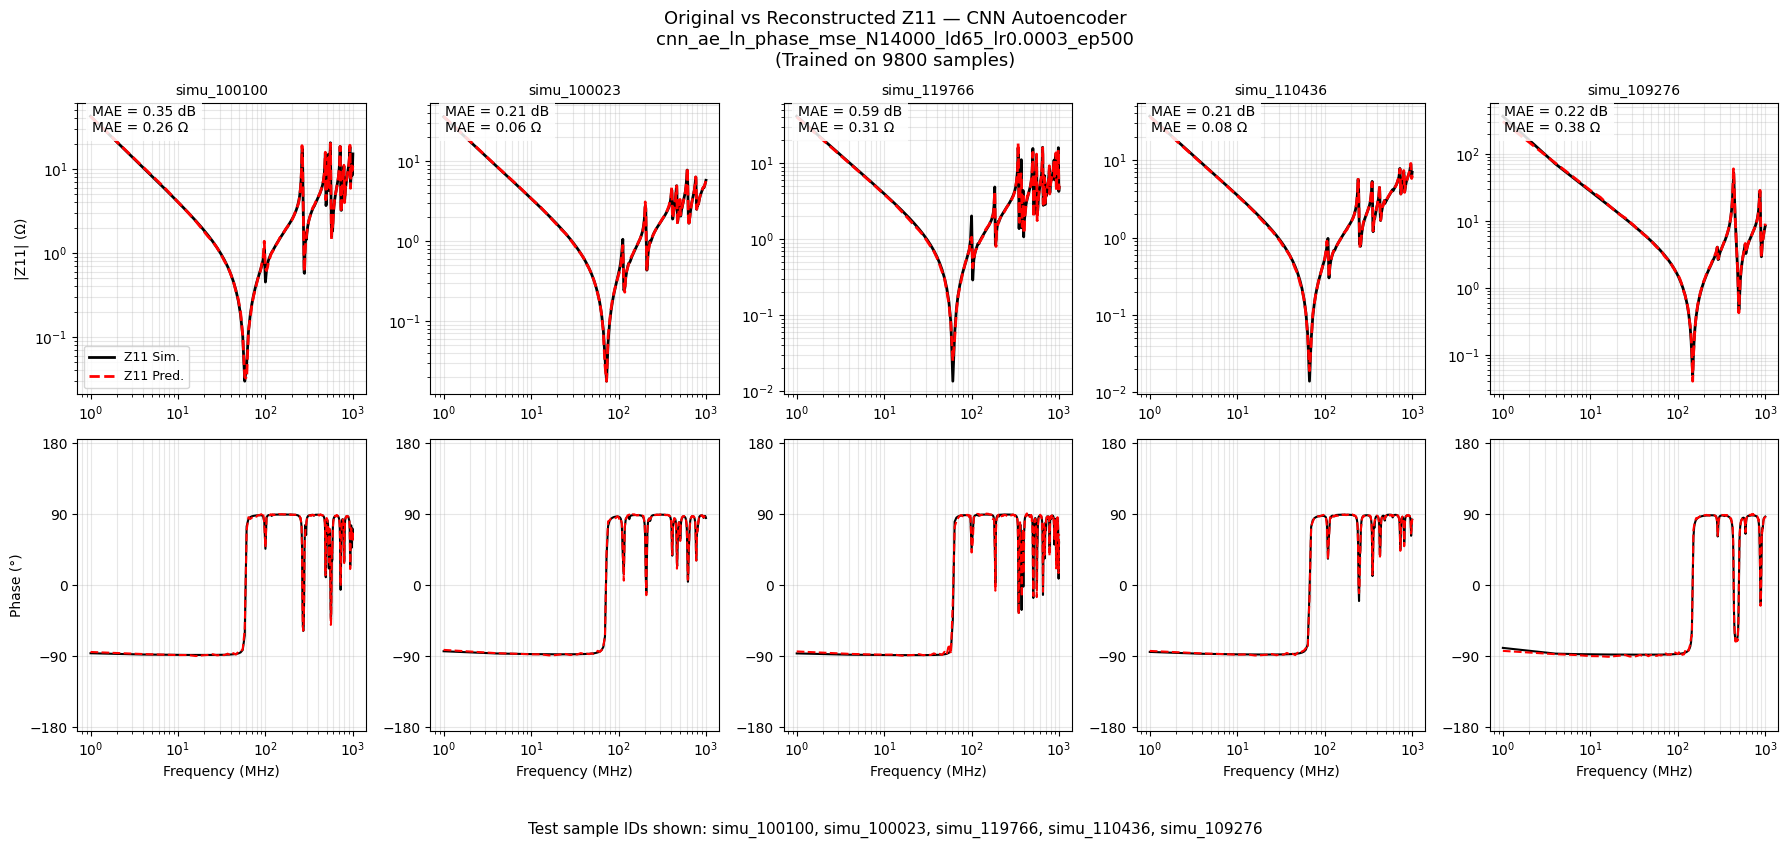

In [33]:
# Cell 13 b — Plot Z11 reconstruction for chosen TEST samples (IDs or random) + MAE

import numpy as np
import matplotlib.pyplot as plt
import mlflow
import os
import tempfile

# ---------------- CONFIG ----------------
N_PLOTS = 5
N_TRAIN_SAMPLES = len(train_loader.dataset)  # automatic

USER_SAMPLE_IDS = [100100, 100023, 119766, 110436, 109276]
# Example:
# USER_SAMPLE_IDS = [100100, 100023, 119766, 110436, 109276]

# Option 2: random test IDs (reproducible)
RANDOM_SEED = 123
# ----------------------------------------

eps = 1e-12  # for safe log10 in dB calculations

assert orig_ohm.shape == pred_ohm.shape, "orig_ohm and pred_ohm shape mismatch"
assert orig_ohm.ndim == 2, "Expected shape [N_samples, N_freq]"
assert len(sid) == orig_ohm.shape[0], "sid length must match orig_ohm rows"

# Use the same frequency grid as evaluation (robust even if Cell 5 wasn't run)
# NOTE: freq_hz_eval should exist from Cell 12 (or define it once globally)
freq_mhz_eval = freq_hz_eval / 1e6  # [Nf] MHz

# Build lookup: simulation id -> row index in orig_ohm/pred_ohm
sid_arr = np.asarray(sid).astype(int)
sid_to_row = {int(s): i for i, s in enumerate(sid_arr)}

# Decide sample IDs (ONLY 2 options)
if USER_SAMPLE_IDS is not None:
    sample_ids = [int(s) for s in USER_SAMPLE_IDS]

    if len(sample_ids) != N_PLOTS:
        raise ValueError(f"Please provide exactly {N_PLOTS} IDs (got {len(sample_ids)}).")

    missing = [s for s in sample_ids if s not in sid_to_row]
    if missing:
        raise ValueError(
            f"These IDs are not in the TEST set: {missing}\n"
            f"Tip: use Cell 13a to list available test IDs."
        )
else:
    rng = np.random.default_rng(RANDOM_SEED)
    sample_ids = rng.choice(sid_arr, size=N_PLOTS, replace=False).tolist()

# Convert sample IDs -> row indices
rows = [sid_to_row[s] for s in sample_ids]

# Increased height to accommodate Phase plots (Row 2)
plt.figure(figsize=(18, 8))

for i, row in enumerate(rows):
    # Retrieve Magnitude Data
    z_sim  = orig_ohm[row]
    z_pred = pred_ohm[row]

    # --- MAE in Ohms (old) ---
    mae_i_ohm = np.mean(np.abs(z_sim - z_pred))

    # --- MAE in dB (NEW) ---
    z_sim_db  = 20.0 * np.log10(z_sim + eps)
    z_pred_db = 20.0 * np.log10(z_pred + eps)
    mae_i_db  = np.mean(np.abs(z_sim_db - z_pred_db))

    # Retrieve Phase Data (Convert Rad -> Deg for clearer plotting)
    p_sim  = np.degrees(orig_phs[row])
    p_pred = np.degrees(pred_phs[row])

    # --- ROW 1: MAGNITUDE ---
    ax = plt.subplot(2, N_PLOTS, i + 1)
    ax.loglog(freq_mhz_eval, z_sim,  color="black", linewidth=2, label="Z11 Sim.")
    ax.loglog(freq_mhz_eval, z_pred, "--", color="red", linewidth=2, label="Z11 Pred.")

    ax.set_title(f"simu_{sample_ids[i]}", fontsize=10)

    if i == 0:
        ax.set_ylabel("|Z11| (Ω)")
        ax.legend(fontsize=9)

    ax.grid(True, which="both", alpha=0.3)

    # Show MAE(dB) + MAE(Ohm) on the plot
    ax.text(
        0.05, 0.90,
        f"MAE = {mae_i_db:.2f} dB\nMAE = {mae_i_ohm:.2f} Ω",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

    # --- ROW 2: PHASE ---
    ax_p = plt.subplot(2, N_PLOTS, i + 1 + N_PLOTS)  # Offset by N_PLOTS to go to next row
    ax_p.semilogx(freq_mhz_eval, p_sim, color="black", linewidth=1.5)
    ax_p.semilogx(freq_mhz_eval, p_pred, "--", color="red", linewidth=1.5)

    ax_p.set_xlabel("Frequency (MHz)")
    ax_p.set_ylim(-185, 185)  # Fixed Phase Range
    ax_p.set_yticks([-180, -90, 0, 90, 180])

    if i == 0:
        ax_p.set_ylabel("Phase (°)")

    ax_p.grid(True, which="both", alpha=0.3)

# Titles
plt.suptitle(
    f"Original vs Reconstructed Z11 — CNN Autoencoder\n"
    f"{RUN_NAME}\n"
    f"(Trained on {N_TRAIN_SAMPLES} samples)",
    fontsize=13
)

plt.figtext(
    0.5, -0.05,
    f"Test sample IDs shown: {', '.join([f'simu_{s}' for s in sample_ids])}",
    ha="center",
    fontsize=11
)

plt.tight_layout()

# Save + log plot to MLflow
with tempfile.TemporaryDirectory() as tmpdir:
    plot_path = os.path.join(tmpdir, f"test_recon_5samples_{RUN_NAME}.png")
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")

    with mlflow.start_run(run_id=RUN_ID):
        mlflow.log_artifact(plot_path, artifact_path="plots")
        mlflow.log_dict({"sample_ids": sample_ids}, "plots/plotted_test_samples.json")

plt.show()
